In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix

# =============================================================
# 1. LOAD VÀ DATA PREPARATION
# =============================================================
#data
npz_path = r'./Data/npz'
data = np.load(npz_path+'/dataset2025_ready2.npz')

X_train_4d = data['X_train']  
y_train    = data['y_train']  
X_test_4d   = data['X_test']  
y_test     = data['y_test']   

# Convert 4D -> 2D 
X_train_full = X_train_4d.mean(axis=(2, 3))  # Shape: (N_train, Bands)
X_test_full  = X_test_4d.mean(axis=(2, 3))   # Shape: (N_test, Bands)

# -------------------------------------------------------------
# NDVI
# -------------------------------------------------------------

ndvi_index = -1  

# without NDVI subset
X_train_no_ndvi = np.delete(X_train_full, ndvi_index, axis=1)
X_test_no_ndvi  = np.delete(X_test_full, ndvi_index, axis=1)

# Band name
class_labels = ['Mangrove', 'Mixed mangrove', 'Aquaculture', 'Built_up', 'Open water']

print(f"with NDVI) : Train {X_train_full.shape} | Test {X_test_full.shape}")
print(f"without NDVI   : Train {X_train_no_ndvi.shape} | Test {X_test_no_ndvi.shape}\n")


# =============================================================
# 2. (K-FOLD CV + TEST)
# =============================================================
def evaluate_rf_model(X_tr, y_tr, X_te, y_te, model_name="Model"):
    print(f"==================================================")
    print(f"   Evaluate: {model_name.upper()}")
    print(f"==================================================")
    
    # 2.1. Stratified 5-Fold Cross Validation in Train
    rf_cv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'f1_macro', 'f1_weighted']
    
    cv_res = cross_validate(rf_cv, X_tr, y_tr, cv=skf, scoring=scoring)
    
    cv_oa = cv_res['test_accuracy'].mean() * 100
    cv_oa_std = cv_res['test_accuracy'].std() * 100
    cv_f1_macro = cv_res['test_f1_macro'].mean() * 100
    cv_f1_weighted = cv_res['test_f1_weighted'].mean() * 100
    
    print(f"[CV 5-Fold Train] Mean OA       : {cv_oa:.2f}% (± {cv_oa_std:.2f}%)")
    print(f"[CV 5-Fold Train] Mean Macro F1 : {cv_f1_macro:.2f}%")
    print(f"[CV 5-Fold Train] Mean Weight F1: {cv_f1_weighted:.2f}%\n")
    
    # 2.2. Huấn luyện Final Model & Đánh giá trên tập Test
    rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_final.fit(X_tr, y_tr)
    y_pred = rf_final.predict(X_te)
    
    # Tính toán chỉ số trên Test
    test_oa = accuracy_score(y_te, y_pred) * 100
    test_kappa = cohen_kappa_score(y_te, y_pred)
    test_f1_macro = f1_score(y_te, y_pred, average='macro') * 100
    test_f1_weighted = f1_score(y_te, y_pred, average='weighted') * 100
    f1_per_class = f1_score(y_te, y_pred, average=None) * 100
    
    print(f"[Test Set Evaluation]")
    print(f"  - Overall Accuracy (OA) : {test_oa:.2f}%")
    print(f"  - Cohen's Kappa (κ)     : {test_kappa:.4f}")
    print(f"  - Macro F1-Score        : {test_f1_macro:.2f}%")
    print(f"  - Weighted F1-Score     : {test_f1_weighted:.2f}%\n")
    
    results = {
        'Model': model_name,
        'CV_OA (%)': f"{cv_oa:.2f} ± {cv_oa_std:.2f}",
        'Test_OA (%)': test_oa,
        'Test_Kappa': test_kappa,
        'Test_Macro_F1 (%)': test_f1_macro,
        'Test_Weighted_F1 (%)': test_f1_weighted,
        'y_pred': y_pred,
        'f1_per_class': f1_per_class
    }
    
    return results

# =============================================================
# 3. Running
# =============================================================
res_no_ndvi = evaluate_rf_model(X_train_no_ndvi, y_train, X_test_no_ndvi, y_test, model_name="RF Without NDVI")
res_with_ndvi = evaluate_rf_model(X_train_full, y_train, X_test_full, y_test, model_name="RF With NDVI")

C:\Users\DELL\AppData\Local\Temp\ipykernel_4528\3963937962.py:23: RuntimeWarning: Mean of empty slice.
  X_train_full = X_train_4d.mean(axis=(2, 3))  # Shape: (N_train, Bands)
D:\Python312\Lib\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\DELL\AppData\Local\Temp\ipykernel_4528\3963937962.py:24: RuntimeWarning: Mean of empty slice.
  X_test_full  = X_test_4d.mean(axis=(2, 3))   # Shape: (N_test, Bands)


Kích thước tập Full (Có NDVI) : Train (6047, 24) | Test (2500, 24)
Kích thước tập Loại bỏ NDVI   : Train (6047, 23) | Test (2500, 23)

   ĐANG ĐÁNH GIÁ: RF WITHOUT NDVI
[CV 5-Fold Train] Mean OA       : 26.62% (± 0.01%)
[CV 5-Fold Train] Mean Macro F1 : 8.41%
[CV 5-Fold Train] Mean Weight F1: 11.20%

[Test Set Evaluation]
  - Overall Accuracy (OA) : 23.88%
  - Cohen's Kappa (κ)     : 0.0000
  - Macro F1-Score        : 7.71%
  - Weighted F1-Score     : 9.21%

   ĐANG ĐÁNH GIÁ: RF WITH NDVI
[CV 5-Fold Train] Mean OA       : 26.62% (± 0.01%)
[CV 5-Fold Train] Mean Macro F1 : 8.41%
[CV 5-Fold Train] Mean Weight F1: 11.20%

[Test Set Evaluation]
  - Overall Accuracy (OA) : 23.88%
  - Cohen's Kappa (κ)     : 0.0000
  - Macro F1-Score        : 7.71%
  - Weighted F1-Score     : 9.21%



In [2]:
# =============================================================
# 4. REPORT
# =============================================================
# 4.1. Report Table
summary_data = {
    'Metric / Indicator': [
        '5-Fold CV Accuracy (%)',
        'Test Overall Accuracy - OA (%)',
        'Test Kappa Coefficient (κ)',
        'Test Macro F1-Score (%)',
        'Test Weighted F1-Score (%)'
    ],
    'RF Without NDVI': [
        res_no_ndvi['CV_OA (%)'],
        f"{res_no_ndvi['Test_OA (%)']:.2f}",
        f"{res_no_ndvi['Test_Kappa']:.4f}",
        f"{res_no_ndvi['Test_Macro_F1 (%)']:.2f}",
        f"{res_no_ndvi['Test_Weighted_F1 (%)']:.2f}"
    ],
    'RF With NDVI': [
        res_with_ndvi['CV_OA (%)'],
        f"{res_with_ndvi['Test_OA (%)']:.2f}",
        f"{res_with_ndvi['Test_Kappa']:.4f}",
        f"{res_with_ndvi['Test_Macro_F1 (%)']:.2f}",
        f"{res_with_ndvi['Test_Weighted_F1 (%)']:.2f}"
    ],
    'Difference (With - Without)': [
        "-",
        f"{res_with_ndvi['Test_OA (%)'] - res_no_ndvi['Test_OA (%)']:+.2f}%",
        f"{res_with_ndvi['Test_Kappa'] - res_no_ndvi['Test_Kappa']:+.4f}",
        f"{res_with_ndvi['Test_Macro_F1 (%)'] - res_no_ndvi['Test_Macro_F1 (%)']:+.2f}%",
        f"{res_with_ndvi['Test_Weighted_F1 (%)'] - res_no_ndvi['Test_Weighted_F1 (%)']:+.2f}%"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n==================================================")
print("   BẢNG SO SÁNH HIỆU NĂNG TỔNG QUAN (TEST SET)")
print("==================================================")
print(df_summary.to_string(index=False))

# 4.2. F1-Score per class
df_f1_classes = pd.DataFrame({
    'Class Name': class_labels,
    'F1 Without NDVI (%)': np.round(res_no_ndvi['f1_per_class'], 2),
    'F1 With NDVI (%)': np.round(res_with_ndvi['f1_per_class'], 2),
    'Gain / Loss (%)': np.round(res_with_ndvi['f1_per_class'] - res_no_ndvi['f1_per_class'], 2)
})

print("\n==================================================")
print("   F1-SCORE PER CLASS")
print("==================================================")
print(df_f1_classes.to_string(index=False))

# Export Excel
with pd.ExcelWriter("RF_NDVI_Ablation_Comparison.xlsx") as writer:
    df_summary.to_excel(writer, sheet_name="Overall_Metrics", index=False)
    df_f1_classes.to_excel(writer, sheet_name="Per_Class_F1", index=False)

print("\n[OK] Exported: RF_NDVI_Ablation_Comparison.xlsx")


   BẢNG SO SÁNH HIỆU NĂNG TỔNG QUAN (TEST SET)
            Metric / Indicator RF Without NDVI RF With NDVI Difference (With - Without)
        5-Fold CV Accuracy (%)    26.62 ± 0.01 26.62 ± 0.01                           -
Test Overall Accuracy - OA (%)           23.88        23.88                      +0.00%
    Test Kappa Coefficient (κ)          0.0000       0.0000                     +0.0000
       Test Macro F1-Score (%)            7.71         7.71                      +0.00%
    Test Weighted F1-Score (%)            9.21         9.21                      +0.00%

   SO SÁNH F1-SCORE TRÊN TỪNG LỚP PHỦ
    Class Name  F1 Without NDVI (%)  F1 With NDVI (%)  Gain / Loss (%)
      Mangrove                 0.00              0.00              0.0
Mixed mangrove                 0.00              0.00              0.0
   Aquaculture                38.55             38.55              0.0
      Built_up                 0.00              0.00              0.0
    Open water                

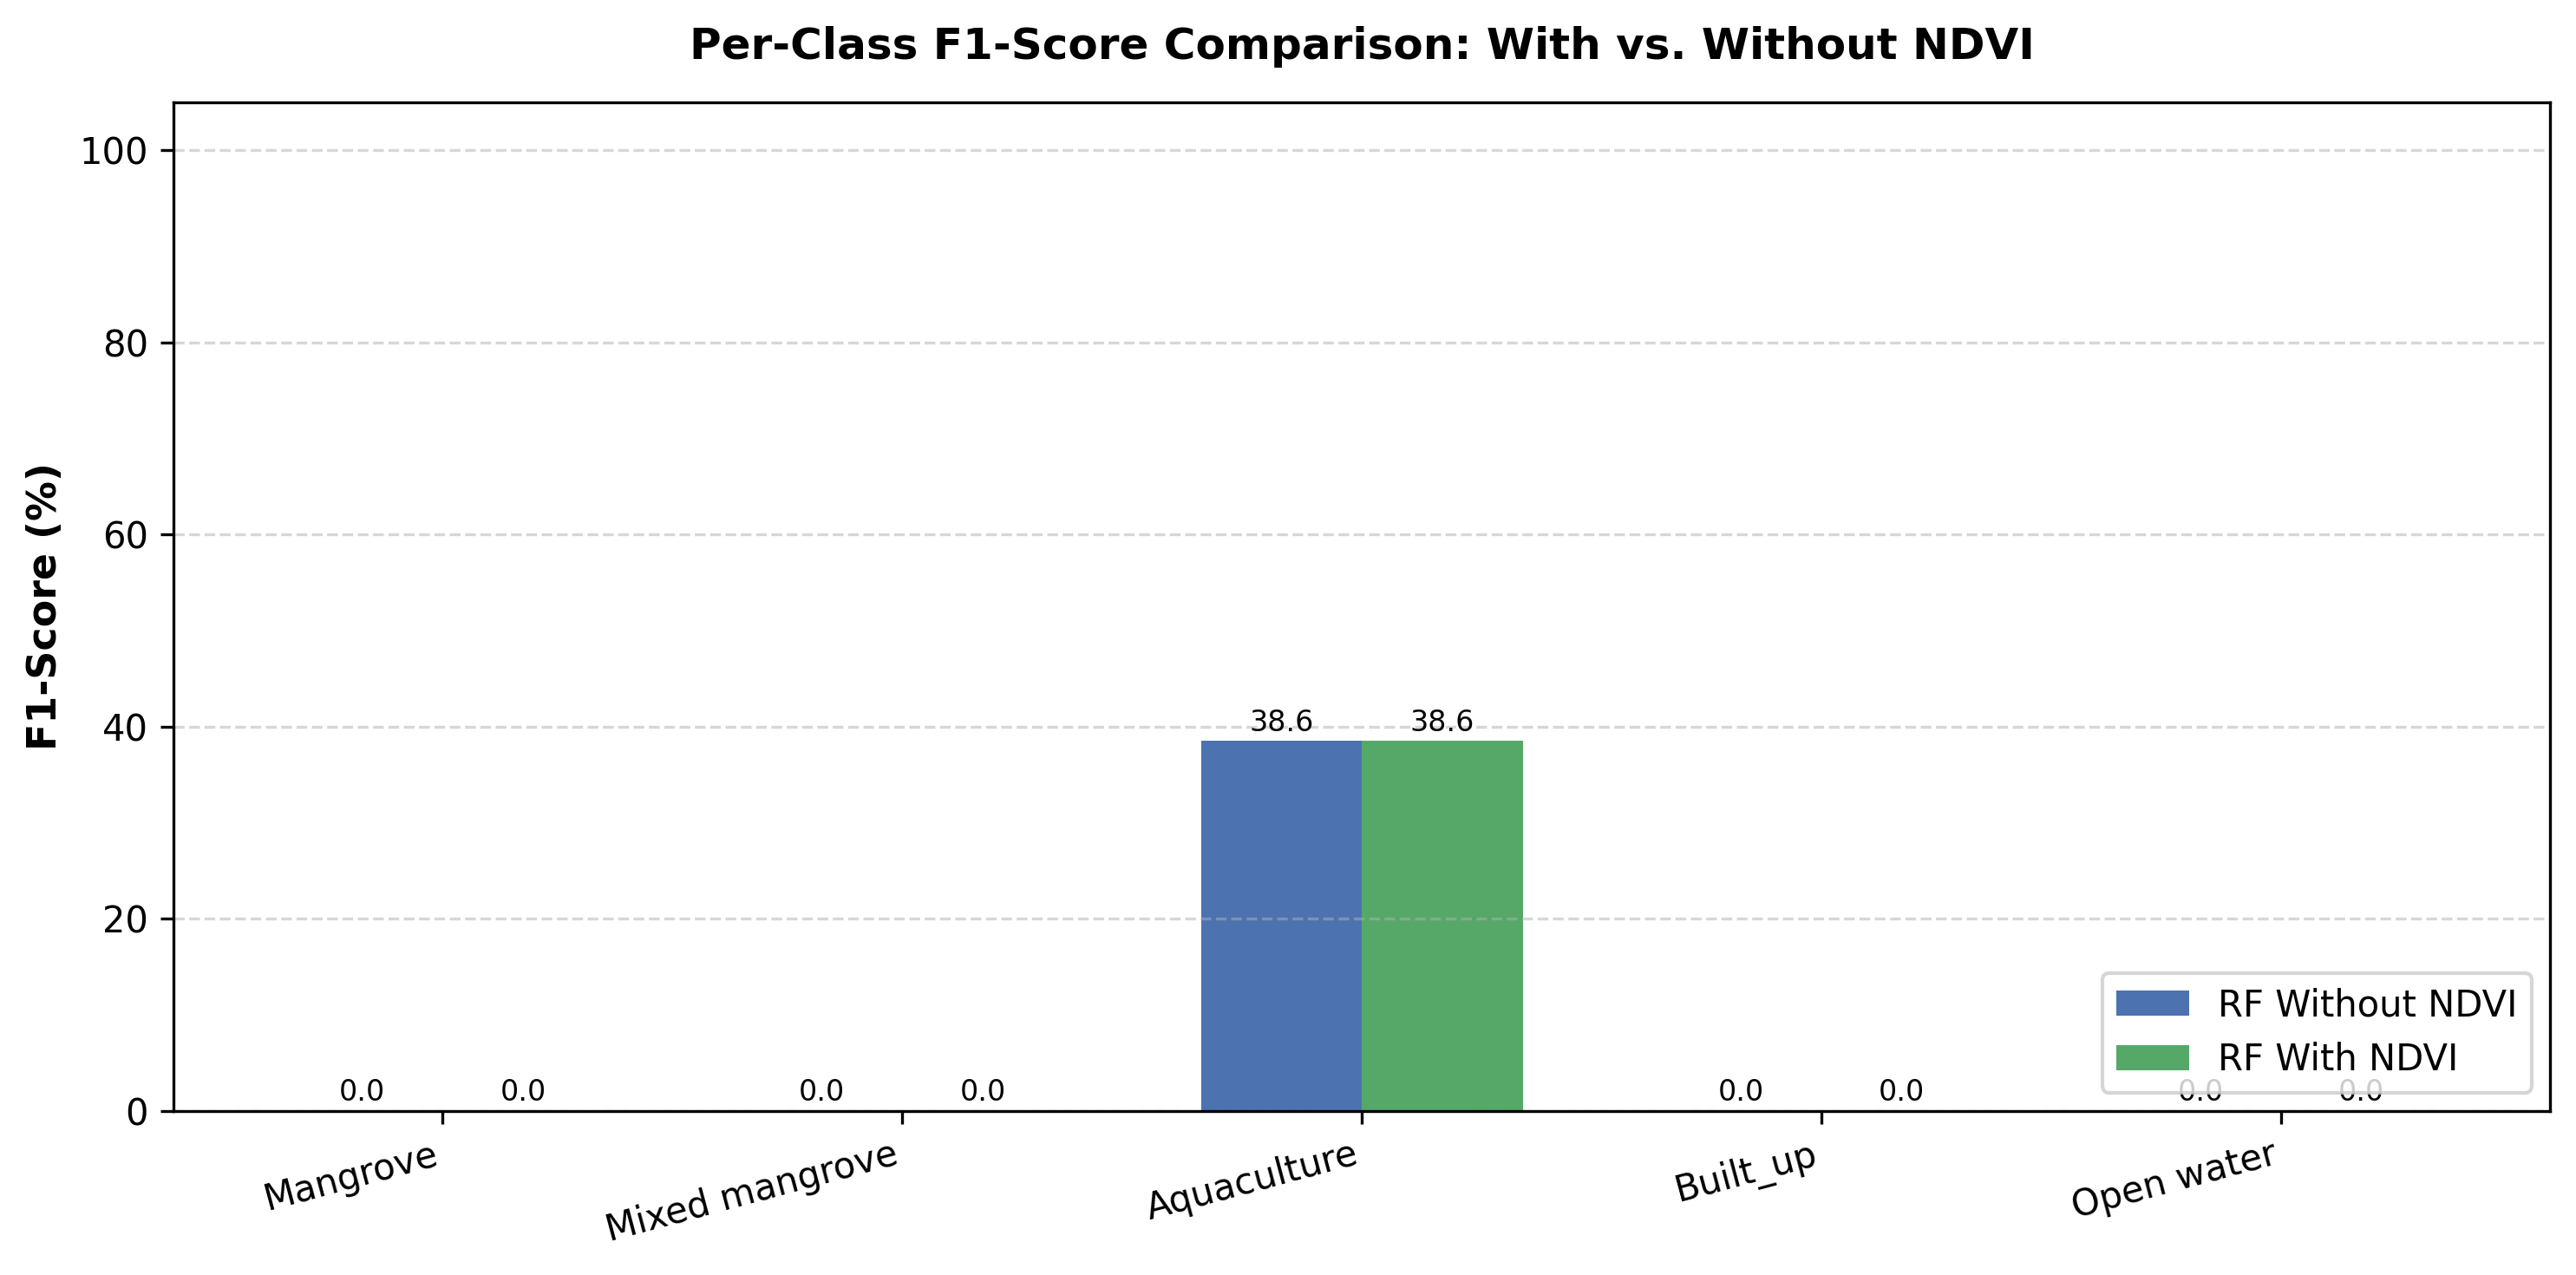

In [3]:
# =============================================================
# 5. Figure
# =============================================================
plt.figure(figsize=(10, 5), dpi=300)

x = np.arange(len(class_labels))
width = 0.35

plt.bar(x - width/2, res_no_ndvi['f1_per_class'], width, label='RF Without NDVI', color='#4C72B0')
plt.bar(x + width/2, res_with_ndvi['f1_per_class'], width, label='RF With NDVI', color='#55A868')

plt.ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
plt.title('Per-Class F1-Score Comparison: With vs. Without NDVI', fontsize=12, fontweight='bold', pad=12)
plt.xticks(x, class_labels, rotation=15, ha='right')
plt.ylim(0, 105)
plt.legend(loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị giá trị trên đỉnh cột
for i in range(len(class_labels)):
    plt.text(i - width/2, res_no_ndvi['f1_per_class'][i] + 1, f"{res_no_ndvi['f1_per_class'][i]:.1f}", ha='center', fontsize=8)
    plt.text(i + width/2, res_with_ndvi['f1_per_class'][i] + 1, f"{res_with_ndvi['f1_per_class'][i]:.1f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('NDVI_Impact_Per_Class_F1.png', dpi=300)
plt.show()